In [136]:
# importacion de librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [137]:
#lectura de datasets
df_victimas = pd.read_csv('Estatal-Víctimas-2015-2025_may2026.csv', encoding='latin1')

df_inegi = pd.read_excel('INEGI_exporta_17_7_2026_15_49_30_limpio.xlsx')

In [138]:
#copia de los dataset
df_copia = df_victimas.copy()
df_copy = df_inegi.copy()


In [139]:
#renombrando columans del df_inegi
df_inegi = df_inegi.rename(columns={
    ' Total': 'Entidad',
    ' Total.1': 'Poblacion'
})

print(df_inegi)

    Unnamed: 0                           Entidad  Poblacion   Hombres  \
0            1                    Aguascalientes    1425607    696683   
1            2                   Baja California    3769020   1900589   
2            3               Baja California Sur     798447    405879   
3            4                          Campeche     928363    456939   
4            5              Coahuila de Zaragoza    3146771   1563669   
5            6                            Colima     731391    360622   
6            7                           Chiapas    5543828   2705947   
7            8                         Chihuahua    3741869   1853822   
8            9                  Ciudad de México    9209944   4404927   
9           10                           Durango    1832650    904866   
10          11                        Guanajuato    6166934   2996454   
11          12                          Guerrero    3540685   1700612   
12          13                           Hidalgo   

In [140]:
#LIMPIANDO DETALLES DE LOS NOMBRES DE LAS ENTIDADES DEL df_entidad: #aqui se elimino un espacio que tenia este estado
df_inegi["Entidad"] = df_inegi["Entidad"].str.strip()

In [141]:
#construyendo el diccionario

poblacion_estados = {'Aguascalientes':1425607,'Baja California':3769020,'Baja California Sur':798447,'Campeche':928363,
                     'Coahuila de Zaragoza':3146771,'Colima':731391,'Chiapas':5543828,'Chihuahua':3741869,'Ciudad de México':9209944,
                     'Durango':1832650,'Guanajuato':6166934,'Guerrero':3540685,'Hidalgo':3082841,'Jalisco':8348151,'México':16992418,
                     'Michoacán de Ocampo':4748846,'Morelos':1971520,'Nayarit':1235456,'Nuevo León':5784442,'Oaxaca':4132148,'Puebla':6583278,
                     'Querétaro':2368467,'Quintana Roo':1857985,'San Luis Potosí':2822255,'Sinaloa':3026943,'Sonora':2944840,'Tabasco':2402598,
                     'Tamaulipas':3527735,'Tlaxcala':1342977,'Veracruz de Ignacio de la Llave':8062579,'Yucatán':2320898,'Zacatecas':1622138}

# !!!!!!!!!!!!!!!!!!!!! PREGUNTAS NUEVAS QUE MANDO ALEJANDRO
# ------- Reformulacion de pregunta #
## para contestarla bien primero hay que:
## Normalizar los datos calculando la tasa de delitos por cada 100,000 habitantes
## primero busca los datos de población por estado el INEGI para los años de su estudio. La formula que deben aplicar para cada estado/estado
## Tasa = (total de delitos / poblacion del estado) x (100,000)

# NOTA:
## TODAS SUS PRUEBAS ESTADISTICAS (ANOVA, REGRESION, ETC.) DEBEN HACERSE CON ESTA TASA NORMALIZADA, NO CON NUMEROS ABSOLUTOS
# 3- ¿La proporción o el promedio de victimas masculinas vs femeninas difiere significativamente? (pruebas estadisticas de comparacion de dos grupos)

In [142]:
meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
         'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

#AGRUPANDO DATOS
resultado = (
    df_copia
    .groupby(["Entidad", "Año", "Sexo"])[meses]
    .sum()
    .reset_index()
)

#print(resultado)





#  suma cada columna de enero a diciembre de cada estado
resultado["Total"] = resultado[meses].sum(axis=1)
print(resultado['Total'])

0        248
1         70
2       3586
3        262
4         74
        ... 
1051    1746
1052      79
1053    2928
1054    1553
1055      65
Name: Total, Length: 1056, dtype: int64


In [143]:

#lo que hace .map() es: busca cada dato en el diccionario, ejemplo:
#para 'puebla' busca 'poblacion_estados["Puebla"]' y encuentra: '6583278' y agrega el numero en la columna 'Poblacion'

resultado["Poblacion"] = resultado["Entidad"].map(poblacion_estados)


#excluyendo los datos de 'no identificado' de la columna 'Sexo'
df_filtrado = df_copia[df_copia["Sexo"] != "No identificado"]
print(df_filtrado['Sexo'])


0         Mujer
1         Mujer
2         Mujer
3         Mujer
4         Mujer
          ...  
80923    Hombre
80924    Hombre
80925    Hombre
80926    Hombre
80927    Hombre
Name: Sexo, Length: 69696, dtype: object


In [144]:
#aqui simplemente filtra por 'Entidad' y 'Sexo'
resultado = (
    df_filtrado
    .groupby(["Entidad", "Sexo"])[meses]
    .sum()
    .reset_index()
)

In [ ]:
#suma los datos de incidentes de enero a diciembre,  esto calcula el numerador de la tasa
resultado["Total"] = resultado[meses].sum(axis=1)

In [ ]:
#se crea y se llena la columna poblacion usando .map, .map trae la poblacion segun sea el estado
resultado["Poblacion"] = resultado["Entidad"].map(poblacion_estados)

In [147]:
resultado["Tasa_pregunta3"] = (
    resultado["Total"] / resultado["Poblacion"]
) * 100000

In [148]:
hombres = resultado[resultado["Sexo"] == "Hombre"]["Tasa_pregunta3"]

In [149]:
mujeres = resultado[resultado['Sexo'] == 'Mujer']['Tasa_pregunta3']

In [150]:
df_filtrado["Sexo"].unique()

array(['Mujer', 'Hombre'], dtype=object)

Paso 6. Hacer la prueba estadística

Aquí es donde entra la inferencia.

Generalmente el flujo es:

Revisar si ambas muestras siguen una distribución aproximadamente normal.
Si sí, usar una prueba t para dos muestras independientes.
Si no, usar una prueba no paramétrica como Mann–Whitney U.

Eso coincide con lo que la profesora les comentó en correos anteriores.

# Lo anterior fue preparacion de los datos, esto será el análisis estadístico

In [151]:
#descripcion de los datos
resultado.groupby("Sexo")["Tasa_pregunta3"].describe()

,count,mean,std,min,25%,50%,75%,max
Sexo,,,,,,,,
Hombre,32.0,1608.976341,709.943926,247.964551,1223.245974,1499.164490,2174.695028,3007.625324
Mujer,32.0,924.296326,461.715225,93.644321,561.994005,960.925389,1231.102480,1948.225268


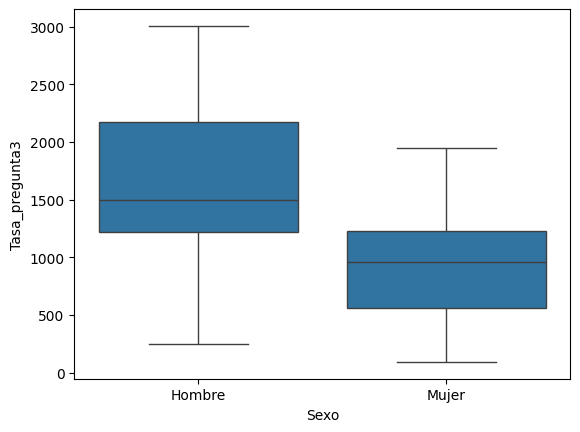

In [ ]:
#grafica de la distribucion de los datos de la tasa entre hombres y mujeres
sns.boxplot(data=resultado,
            x="Sexo",
            y="Tasa_pregunta3")

plt.show()

# hipotesis:
Hipótesis nula (H₀): Los datos siguen una distribución normal.

CRITERIO:

Si p > 0.05
No hay evidencia suficiente para decir que los datos no son normales.

Se considera que los datos pueden tratarse como normales.



Si p ≤ 0.05
Se rechaza la hipótesis de normalidad.

Se concluye que los datos no siguen una distribución normal.

In [154]:
from scipy.stats import shapiro

shapiro(resultado['Tasa_pregunta3'])

ShapiroResult(statistic=np.float64(0.9713899638324678), pvalue=np.float64(0.1428690999765505))

¿Por qué no se le hace la prueba de normalidad a las incidencias pero si a Tasa_pregunta3?

Porque las incidencias están influenciadas por el tamaño de la población. Un estado muy poblado casi siempre tendrá más delitos en números absolutos que uno pequeño, aunque el riesgo real sea menor.

Al normalizar, obtienes una medida comparable entre estados o años. Esa es la variable que normalmente analizarías y sobre la que tendría sentido comprobar la normalidad.

En este caso como:
0.1429 > 0.05

Los datos de la columna Tasa_pregunta3 son compatibles con una distribución normal.

 Es decir, con esta prueba no hay evidencia suficiente para afirmar que la distribución sea distinta de una normal.

CONCLUSION DE LA NORMALIDAD:
Se aplicó la prueba de normalidad de Shapiro-Wilk sobre la variable Tasa_pregunta3. Se obtuvo un valor de p = 0.1429, superior al nivel de significancia de 0.05. Por lo tanto, no se rechaza la hipótesis nula y se concluye que los datos son compatibles con una distribución normal.

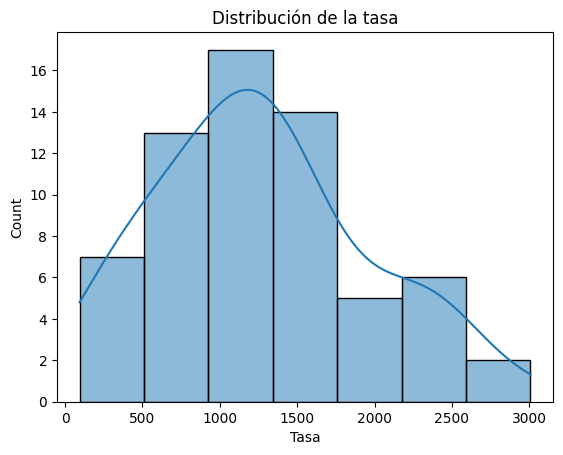

In [155]:
#visualizacion 
sns.histplot(resultado["Tasa_pregunta3"], kde=True)

plt.xlabel("Tasa")
plt.title("Distribución de la tasa")
plt.show()

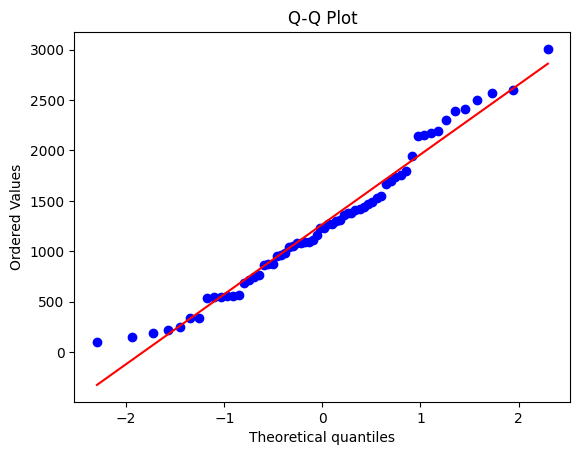

In [156]:
from scipy.stats import probplot
import matplotlib.pyplot as plt

probplot(resultado["Tasa_pregunta3"], dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [157]:
print(resultado['Tasa_pregunta3'].skew())

0.422031569358874


entre -0.5 y 0.5 → aproximadamente simétrica.

entre -1 y -0.5 o entre 0.5 y 1 → asimetría moderada.

mayor a 1 → asimetría fuerte.

0.42 es perfectamente compatible con la conclusión de que la distribución es aproximadamente normal.

Se evaluó la normalidad de la variable Tasa_pregunta3 de manera general mediante histogramas, Q-Q plot y la prueba de Shapiro-Wilk.

Dado que el análisis consiste en comparar dos grupos (hombres y mujeres), también se evaluó la normalidad de cada grupo por separado

In [158]:
#ahora haciendo prueba pro separado de datos para hombre y mujer
hombres = resultado[resultado["Sexo"] == "Hombre"]["Tasa_pregunta3"]

mujeres = resultado[resultado["Sexo"] == "Mujer"]["Tasa_pregunta3"]

from scipy.stats import shapiro

print("Hombres:", shapiro(hombres))
print("Mujeres:", shapiro(mujeres))

Hombres: ShapiroResult(statistic=np.float64(0.9730865534012149), pvalue=np.float64(0.5885760139261845))
Mujeres: ShapiroResult(statistic=np.float64(0.982827892193013), pvalue=np.float64(0.8763038404796146))


Se aplicó la prueba de Shapiro-Wilk a las tasas de víctimas masculinas y femeninas por separado. En ambos grupos se obtuvieron valores de p superiores a 0.05 (hombres: p = 0.5886; mujeres: p = 0.8763), por lo que no se rechaza la hipótesis nula. Se concluye que ambas distribuciones son compatibles con una distribución normal, permitiendo el uso de pruebas paramétricas para comparar ambos grupos.

Hipótesis

Para la prueba t de comparación de dos grupos:

Hipótesis nula (H₀):

μ
hombres
	​

=μ
mujeres
	​


Es decir:

No existe diferencia significativa entre el promedio de la tasa de víctimas masculinas y femeninas.


In [159]:
# separando los datos para una mayor comparacion
hombres = resultado[resultado["Sexo"]=="Hombre"]["Tasa_pregunta3"]
mujeres = resultado[resultado["Sexo"]=="Mujer"]["Tasa_pregunta3"]


In [ ]:
# prueba estadistica 
# Aplicar una prueba de comparación de grupos
from scipy.stats import ttest_ind

t, p = ttest_ind(hombres, mujeres)

print(p)

2.350377046059646e-05


#RESULTADOS
CRITERIO: 

Si p > 0.05 → no se rechaza H₀.

Si p ≤ 0.05 → se rechaza H₀.

como: 0.0000235<0.05

# ENTONCES SE RECHAZA LA HIPOTESIS NULA



Se realizó una prueba t de Student para muestras independientes con el objetivo de determinar si existe una diferencia significativa entre la tasa promedio de víctimas masculinas y femeninas por cada 100,000 habitantes. El valor p obtenido fue de 0.0000235, menor al nivel de significancia de 0.05, por lo que se rechaza la hipótesis nula. Esto indica que existe evidencia estadística suficiente para afirmar que la tasa promedio de víctimas masculinas y femeninas difiere significativamente.

In [161]:
print("Media hombres:", hombres.mean())
print("Media mujeres:", mujeres.mean())

Media hombres: 1608.9763414024942
Media mujeres: 924.2963257594708


Además la media de la tasa de víctimas masculinas (1608.97 por cada 100,000 habitantes) fue superior a la media de la tasa de víctimas femeninas (924.29 por cada 100,000 habitantes), lo que indica que las víctimas masculinas presentan una mayor tasa promedio.

In [162]:
# ¿Es necesario decir "por cuánto"?
diferencia = hombres.mean() - mujeres.mean()
print(diferencia)



684.6800156430234


En promedio, la tasa de victimización masculina fue 684.68 unidades mayor que la femenina, considerando la tasa por cada 100,000 habitantes.

# conclusion
La prueba t de Student indicó que existe una diferencia estadísticamente significativa entre las tasas promedio de víctimas masculinas y femeninas (p = 0.0000235). Además, la tasa promedio de víctimas masculinas fue 684.68 unidades mayor que la tasa promedio de víctimas femeninas, considerando la tasa por cada 100,000 habitantes.

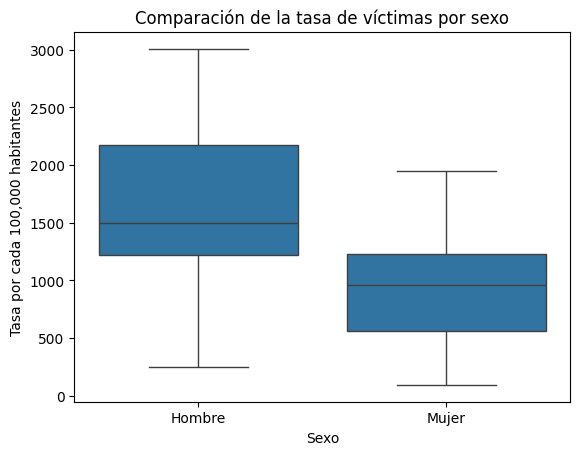

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=resultado,
    x="Sexo",
    y="Tasa_pregunta3"
)

plt.title("Comparación de la tasa de víctimas por sexo")
plt.xlabel("Sexo")
plt.ylabel("Tasa por cada 100,000 habitantes")
plt.show()

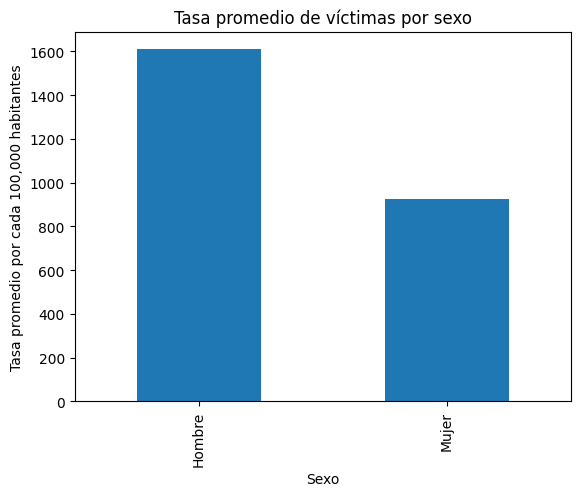

In [164]:
promedios = resultado.groupby("Sexo")["Tasa_pregunta3"].mean()

promedios.plot(kind="bar")

plt.ylabel("Tasa promedio por cada 100,000 habitantes")
plt.title("Tasa promedio de víctimas por sexo")
plt.show()

# Pregunta 6
# ¿Existe una asociación significativa entre el tipo de delito cometido y el género de la victima o son variables completamente independientes? (Chi cuadrado)